In [1]:
import sys
sys.path.append('../')
import utils


import numpy as np
import scipy as sp
import utils.Camel.models as models
import utils.Camel.sampling as sampling
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import transforms

/home/mdrnevich/dev/QuasiML_paper/QuasiML/ToyModels/../utils/__init__.py:5: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. 

  from . import plotting


# Generate and save some data

## Choose the parameters of the distributions

In [2]:
# base/source density
mixture_coef = (4, -1)  # coefficients of the pdf terms
scales = (2.5, 2.3)  # input scaling (x -> x/scale)

# signed target density
neg_mixture_coef = (2, -1)  # coefficients of the pdf terms
neg_scales = (2, 1.2)  # input scaling (x -> x/scale)

# sample size and train/val/test splits
N = int(4e6)
training_cutoff = int(0.5 * N) # 50%
validation_cutoff = int(0.65 * N) # 15%
testing_cutoff = int(1.0 * N) # 35%

SAVE_DATA = True

## Generate and save the source nonnegative Gaussian mixture data using direct samples

In [5]:
xy = sampling.sample_camel(N, mixture_coef, scales=scales)  # get positively weighted samples
xy = np.concatenate([xy, np.ones((N,1))], axis=1) # append weights of 1 for later use

if SAVE_DATA is True:
    np.save('data/base_distribution_data_train.npy', xy[:training_cutoff])
    np.save('data/base_distribution_data_val.npy', xy[training_cutoff:validation_cutoff])
    np.save('data/base_distribution_data_test.npy', xy[validation_cutoff:testing_cutoff])

## Generate and save the source nonnegative Gaussian mixture data using Monte Carlo sampling with negative weights

In [3]:
mc_samples = sampling.sample_camel_mc(N, mixture_coef, scales=scales, basis="cartesian", weight_scales=(1, 1), weight_spreads=(0, 0))

if SAVE_DATA is True:
    np.save('data/base_distribution_mc_data_train.npy', mc_samples[:training_cutoff])
    np.save('data/base_distribution_mc_data_val.npy', mc_samples[training_cutoff:validation_cutoff])
    np.save('data/base_distribution_mc_data_test.npy', mc_samples[validation_cutoff:testing_cutoff])

## Generate and save the target signed Gaussian mixture data using Monte Carlo sampling with negative weights

In [4]:
neg_mc_samples = sampling.sample_camel_mc(N, neg_mixture_coef, scales=neg_scales, basis="cartesian", weight_scales=(1, 1), weight_spreads=(0, 0))

if SAVE_DATA is True:
    np.save('data/target_distribution_mc_data_train.npy', neg_mc_samples[:training_cutoff])
    np.save('data/target_distribution_mc_data_val.npy', neg_mc_samples[training_cutoff:validation_cutoff])
    np.save('data/target_distribution_mc_data_test.npy', neg_mc_samples[validation_cutoff:testing_cutoff])

## Compute the radial components using the MC samples

In [6]:
r = np.sqrt(mc_samples[:,0]**2 + mc_samples[:,1]**2)  # compute the radial coordinate
neg_r = np.sqrt(neg_mc_samples[:,0]**2 + neg_mc_samples[:,1]**2)  # compute the radial coordinate

# Compare the datasets

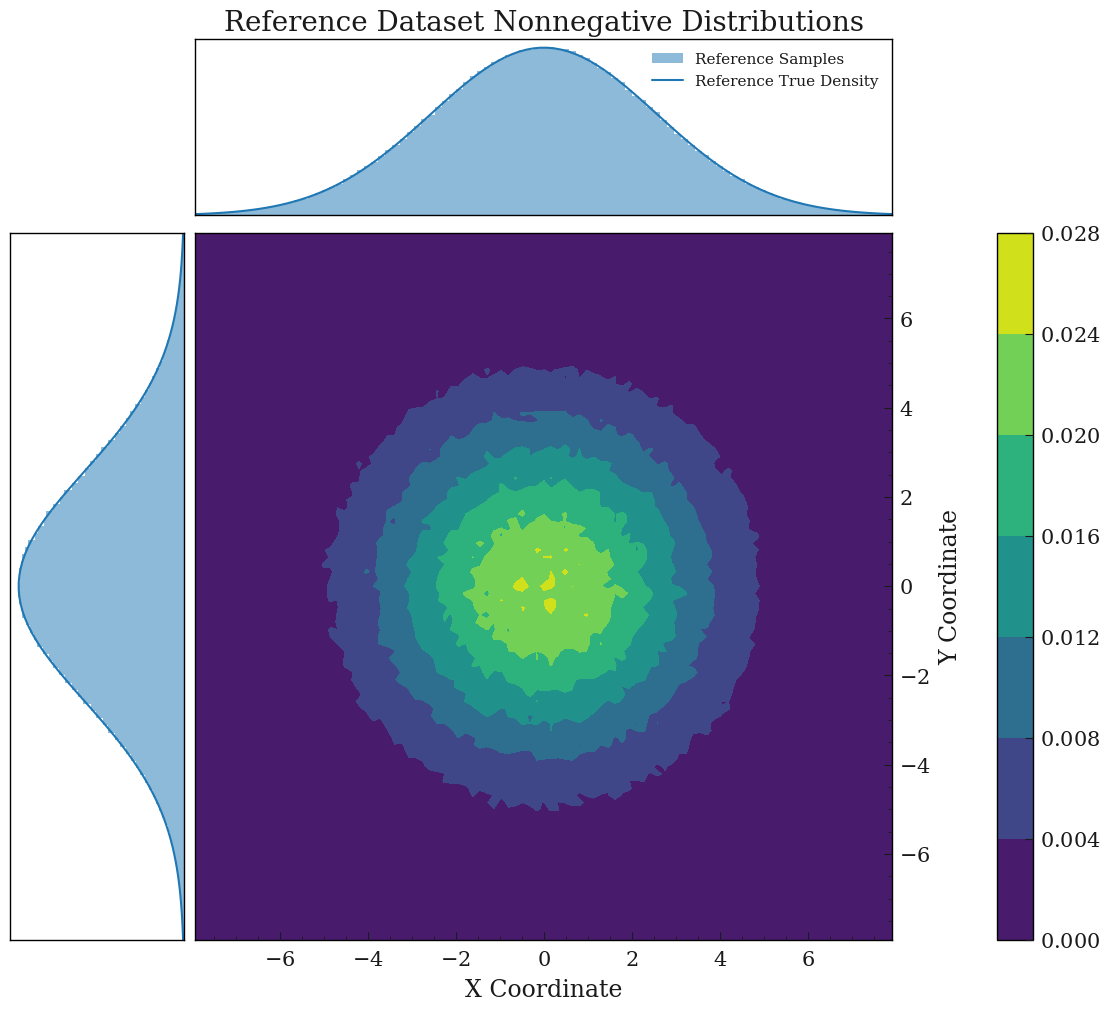

In [7]:
# Start with a square Figure.
fig = plt.figure(figsize=(11, 10), layout='constrained')
# Add a gridspec with two rows and two columns and a ratio of 1 to 4 between
# the size of the marginal axes and the main axes in both directions.
# Also adjust the subplot parameters for a square plot.
gs = fig.add_gridspec(2, 2,  width_ratios=(1, 4), height_ratios=(1, 4))
                      #left=0.1, right=0.9, bottom=0.1, top=0.9)
                      #wspace=0.05, hspace=0.05)
# Create the Axes.
ax = fig.add_subplot(gs[1, 1])
ax_x = fig.add_subplot(gs[0, 1])#, sharex=ax)
ax_y = fig.add_subplot(gs[1, 0])#, sharey=ax)

rot = transforms.Affine2D().rotate_deg(-90)


xmax = 8
bins = np.linspace(-xmax,xmax,100)


p_x_A = mixture_coef[0]*sp.stats.norm.pdf(bins, 0, scales[0])
p_x_B = mixture_coef[1]*sp.stats.norm.pdf(bins, 0, scales[1])
p_x = (p_x_A + p_x_B) / sum(mixture_coef)

ax_x.hist(mc_samples[:,0], bins=bins, weights=mc_samples[:,-1], density=True, label="Reference Samples", color="tab:blue", alpha=0.5)
ax_x.plot(bins, p_x, label="Reference True Density", color="tab:blue")
ax_x.set_xlim([bins.min(), bins.max()])
ax_x.set_xticks([])
ax_x.set_yticks([])
ax_x.legend(frameon=False, fontsize=11)
ax_x.set_title("Reference Dataset Nonnegative Distributions", fontsize="20")

#y_hist = np.histogram(mc_samples[:,1], bins=bins, weights=mc_samples[:,-1], density=True)
#bin_middles = (bins[:-1] + bins[1:])/2

ax_y.hist(mc_samples[:,1], bins=bins, weights=mc_samples[:,-1], density=True, label="Reference Samples", color="tab:blue", alpha=0.5,
         orientation='horizontal')
ax_y.plot(bins, p_x, label="Reference True Density", color="tab:blue", transform=rot+ax_y.transData)
ax_y.set_ylim([bins.min(), bins.max()])
ax_y.invert_xaxis()
ax_y.set_xticks([])
ax_y.set_yticks([])


###########################################################################

x = mc_samples[:,0]
y = mc_samples[:,1]

hist, xedges, yedges = np.histogram2d(x,y,bins=(bins,bins), weights=mc_samples[:,-1], density=True)
hist = hist.T

mean_xbins = (xedges[1:] + xedges[:-1]) / 2
mean_ybins = (yedges[1:] + yedges[:-1]) / 2
Xedges, Yedges = np.meshgrid(mean_xbins, mean_ybins)

#im = ax.pcolormesh(Xedges, Yedges, hist) # for histogram
im = ax.contourf(Xedges, Yedges, np.clip(hist, 0, None))#, levels=levels)
ax.set_xlabel("X Coordinate", fontsize=17)
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.set_ylabel("Y Coordinate", fontsize=17)

#norm = mpl.colors.Normalize(vmin=0, vmax =hist.)
fig.colorbar(im, ax=ax)

#fig.suptitle("Reference Dataset Nonnegative Camel Distributions", fontsize="18")


#fig.tight_layout()
#fig.savefig("Toy_prob_ref_distributions.pdf")

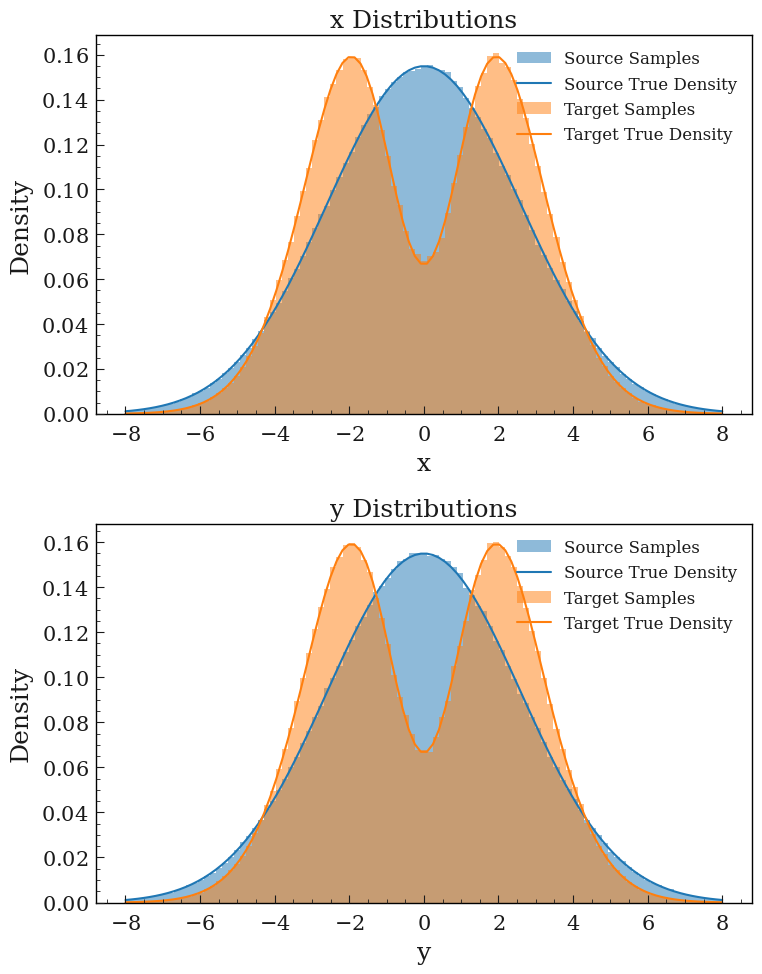

In [8]:
fig, ax = plt.subplots(2, 1)
fig.set_size_inches(8,10)

xmax = 8
t = np.linspace(-xmax,xmax,100)
p_x_A = mixture_coef[0]*sp.stats.norm.pdf(t, 0, scales[0])
p_x_B = mixture_coef[1]*sp.stats.norm.pdf(t, 0, scales[1])
p_x = (p_x_A + p_x_B) / sum(mixture_coef)

p_x2_A = neg_mixture_coef[0]*sp.stats.norm.pdf(t, 0, neg_scales[0])
p_x2_B = neg_mixture_coef[1]*sp.stats.norm.pdf(t, 0, neg_scales[1])
p_x2 = (p_x2_A + p_x2_B) / sum(neg_mixture_coef)

bins = t
ax[0].hist(mc_samples[:,0], bins=bins, weights=mc_samples[:,-1], density=True, label="Source Samples", color="tab:blue", alpha=0.5)
ax[0].plot(t, p_x, label="Source True Density", color="tab:blue")
ax[0].hist(neg_mc_samples[:,0], bins=bins, weights=neg_mc_samples[:,-1], density=True, label="Target Samples", color="tab:orange", alpha=0.5)
ax[0].plot(t, p_x2, label="Target True Density", color="tab:orange")

ax[0].set_xlabel("x")
ax[0].set_ylabel("Density")
ax[0].set_title("x Distributions")
ax[0].legend()


#######################

bins = t
ax[1].hist(mc_samples[:,1], bins=bins, weights=mc_samples[:,-1], density=True, label="Source Samples", color="tab:blue", alpha=0.5)
ax[1].plot(t, p_x, label="Source True Density", color="tab:blue")
ax[1].hist(neg_mc_samples[:,1], bins=bins, weights=neg_mc_samples[:,-1], density=True, label="Target Samples", color="tab:orange", alpha=0.5)
ax[1].plot(t, p_x2, label="Target True Density", color="tab:orange")

ax[1].set_xlabel("y")
ax[1].set_ylabel("Density")
ax[1].set_title("y Distributions")
ax[1].legend()

fig.tight_layout()

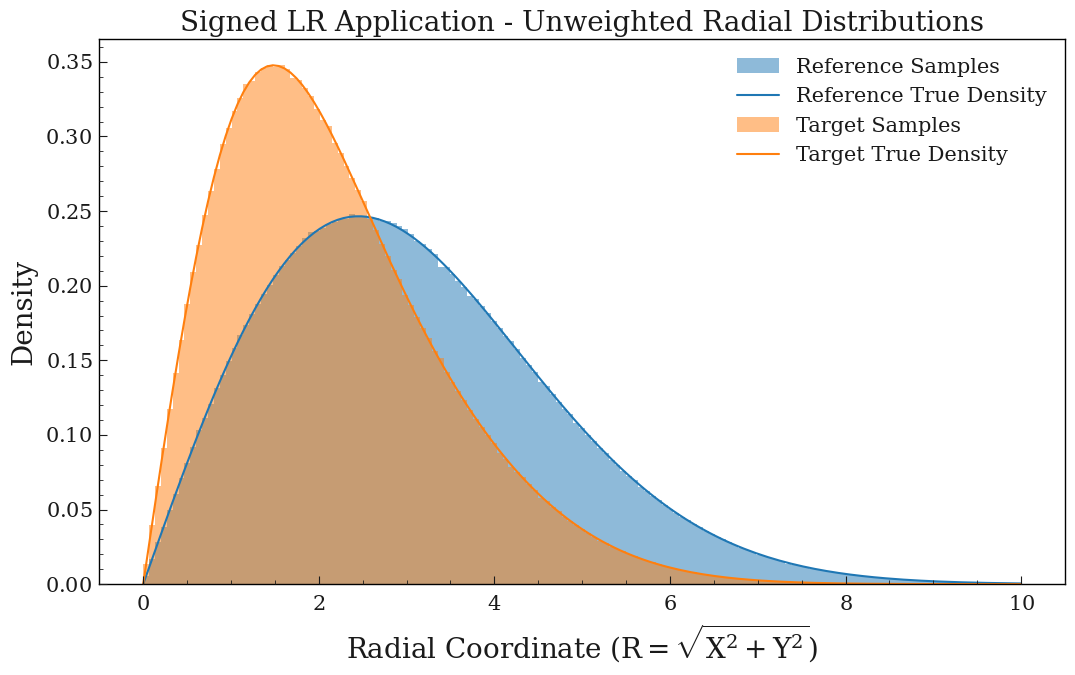

In [9]:
fig, ax = plt.subplots()
fig.set_size_inches(11,7)

xmax = 10  # boundary for plotting
t = np.linspace(0, xmax, 150)
p_r = models.camel_radial_sampling_density(t, mixture_coef, scales=scales, logprob=False) # look at the true radial densities
p_r2 = models.camel_radial_sampling_density(t, neg_mixture_coef, scales=neg_scales, logprob=False) # look at the true radial densities

bins = t
ax.hist(r, bins=bins, density=True, label="Reference Samples", color="tab:blue", alpha=0.5)
ax.plot(t, p_r, label="Reference True Density", color="tab:blue")
ax.hist(neg_r, bins=bins, density=True, label="Target Samples", color="tab:orange", alpha=0.5)
ax.plot(t, p_r2, label="Target True Density", color="tab:orange")

ax.set_xlabel("Radial Coordinate ($R = \sqrt{X^2+Y^2}$)", fontsize=20)
ax.set_ylabel("Density", fontsize=20)
ax.set_title("Signed LR Application - Unweighted Radial Distributions", fontsize=20)
ax.legend(fontsize=15)

fig.tight_layout()
#fig.savefig("Toy_quasi_radial_distributions.pdf")

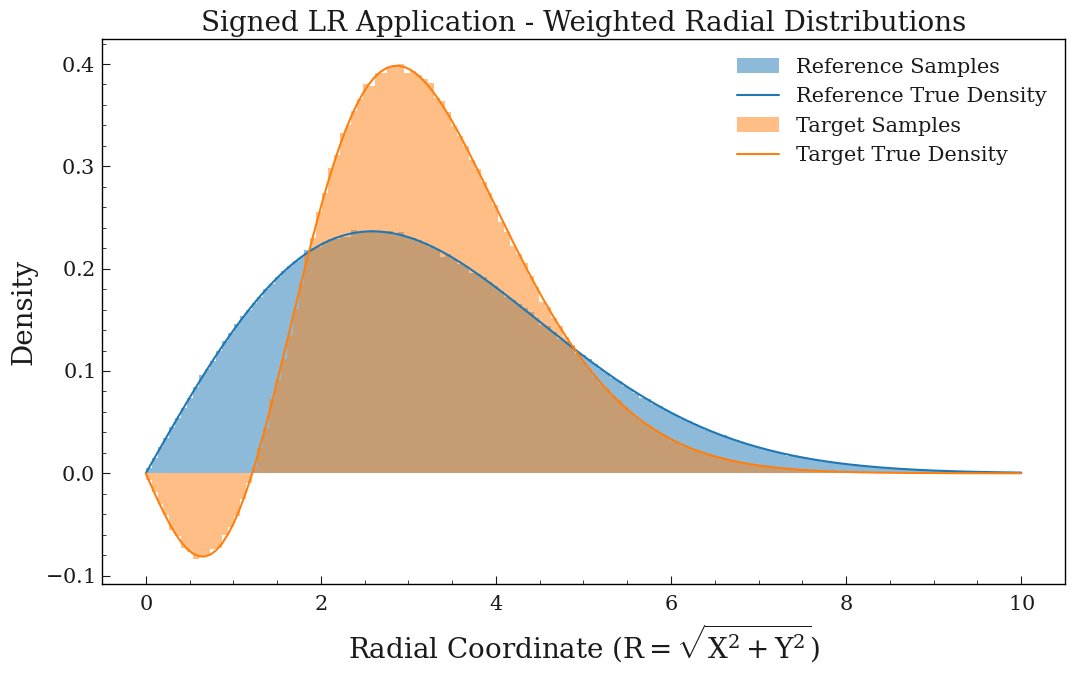

In [10]:
fig, ax = plt.subplots()
fig.set_size_inches(11,7)

xmax = 10  # boundary for plotting
t = np.linspace(0, xmax, 150)
p_r = models.camel_radial_density(t, mixture_coef, scales=scales, logprob=False) # look at the true radial densities
p_r2 = models.camel_radial_density(t, neg_mixture_coef, scales=neg_scales, logprob=False) # look at the true radial densities

bins = t
ax.hist(r, bins=bins, weights=mc_samples[:,-1], density=True, label="Reference Samples", color="tab:blue", alpha=0.5)
ax.plot(t, p_r, label="Reference True Density", color="tab:blue")
ax.hist(neg_r, bins=bins, weights=neg_mc_samples[:,-1], density=True, label="Target Samples", color="tab:orange", alpha=0.5)
ax.plot(t, p_r2, label="Target True Density", color="tab:orange")

ax.set_xlabel("Radial Coordinate ($R = \sqrt{X^2+Y^2}$)", fontsize=20)
ax.set_ylabel("Density", fontsize=20)
ax.set_title("Signed LR Application - Weighted Radial Distributions", fontsize=20)
ax.legend(fontsize=15)

fig.tight_layout()
#fig.savefig("Toy_quasi_radial_distributions.pdf")

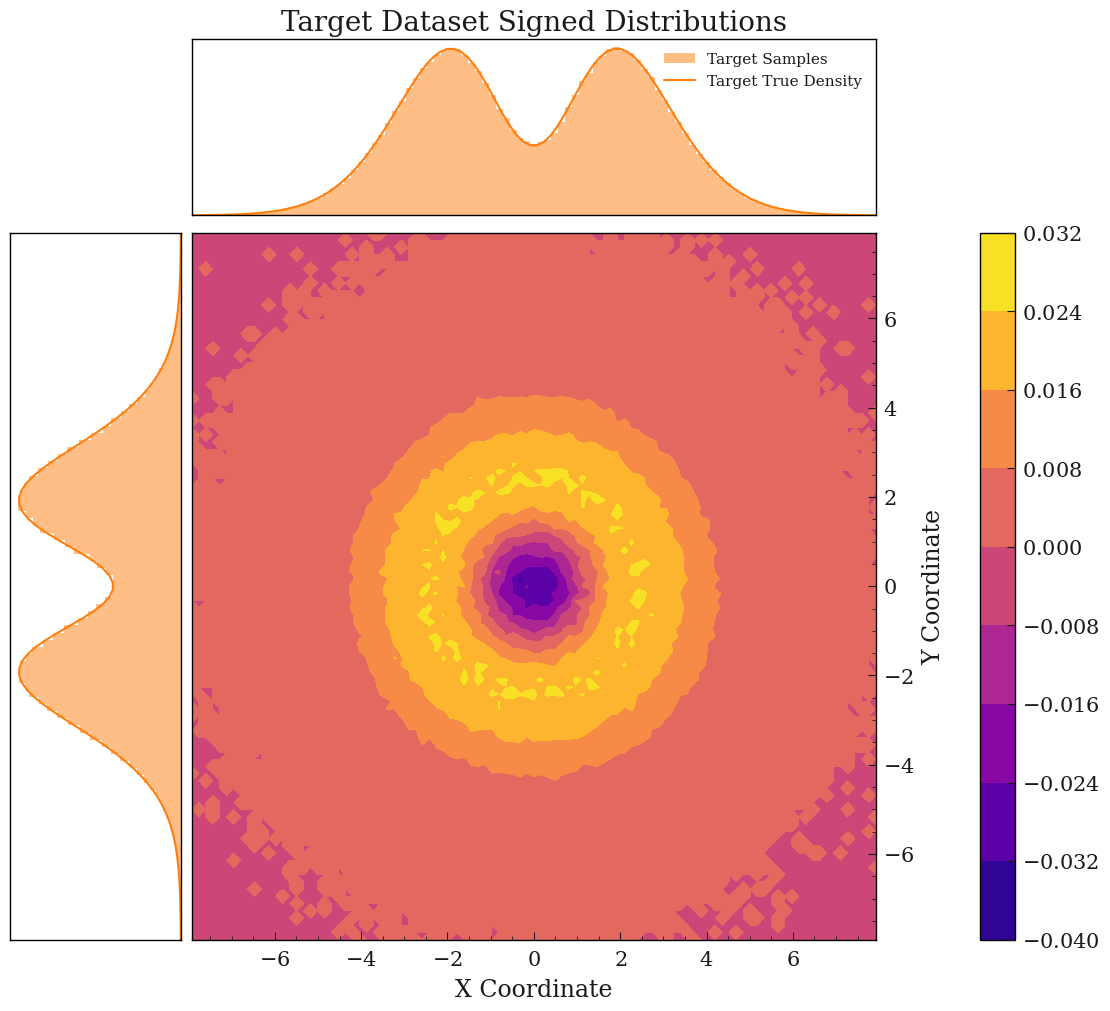

In [12]:
# Start with a square Figure.
fig = plt.figure(figsize=(11, 10), layout='constrained')
# Add a gridspec with two rows and two columns and a ratio of 1 to 4 between
# the size of the marginal axes and the main axes in both directions.
# Also adjust the subplot parameters for a square plot.
gs = fig.add_gridspec(2, 2,  width_ratios=(1, 4), height_ratios=(1, 4))
                      #left=0.1, right=0.9, bottom=0.1, top=0.9)
                      #wspace=0.05, hspace=0.05)
# Create the Axes.
ax = fig.add_subplot(gs[1, 1])
ax_x = fig.add_subplot(gs[0, 1])#, sharex=ax)
ax_y = fig.add_subplot(gs[1, 0])#, sharey=ax)

rot = transforms.Affine2D().rotate_deg(-90)


xmax = 8
bins = np.linspace(-xmax,xmax,100)


p_x2_A = neg_mixture_coef[0]*sp.stats.norm.pdf(bins, 0, neg_scales[0])
p_x2_B = neg_mixture_coef[1]*sp.stats.norm.pdf(bins, 0, neg_scales[1])
p_x2 = (p_x2_A + p_x2_B) / sum(neg_mixture_coef)

ax_x.hist(neg_mc_samples[:,0], bins=bins, weights=neg_mc_samples[:,-1], density=True, label="Target Samples", color="tab:orange", alpha=0.5)
ax_x.plot(bins, p_x2, label="Target True Density", color="tab:orange")
ax_x.set_xlim([bins.min(), bins.max()])
ax_x.set_xticks([])
ax_x.set_yticks([])
ax_x.legend(frameon=False, fontsize=11)
ax_x.set_title("Target Dataset Signed Distributions", fontsize="20")

#y_hist = np.histogram(mc_samples[:,1], bins=bins, weights=mc_samples[:,-1], density=True)
#bin_middles = (bins[:-1] + bins[1:])/2

ax_y.hist(neg_mc_samples[:,1], bins=bins, weights=neg_mc_samples[:,-1], density=True, label="Target Samples", color="tab:orange", alpha=0.5,
         orientation='horizontal')
ax_y.plot(bins, p_x2, label="Target True Density", color="tab:orange", transform=rot+ax_y.transData)
ax_y.set_ylim([bins.min(), bins.max()])
ax_y.invert_xaxis()
ax_y.set_xticks([])
ax_y.set_yticks([])


###########################################################################

x2 = neg_mc_samples[:,0]
y2 = neg_mc_samples[:,1]

hist2, xedges2, yedges2 = np.histogram2d(x2,y2,bins=(bins,bins), weights=neg_mc_samples[:,-1], density=True)
hist2 = hist2.T

mean_xbins = (xedges2[1:] + xedges2[:-1]) / 2
mean_ybins = (yedges2[1:] + yedges2[:-1]) / 2
Xedges, Yedges = np.meshgrid(mean_xbins, mean_ybins)

#im = ax.pcolormesh(Xedges, Yedges, hist) # for histogram
im = ax.contourf(Xedges, Yedges, hist2, cmap=matplotlib.colormaps['plasma'])
ax.set_xlabel("X Coordinate", fontsize=17)
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.set_ylabel("Y Coordinate", fontsize=17)
fig.colorbar(im, ax=ax)

#fig.suptitle("Target Dataset Signed Camel Distributions", fontsize="19")


#fig.tight_layout()
#fig.savefig("Toy_quasi_target_distributions.pdf")